<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB34 · Stable-Baselines3: PPO como lo usan los profesionales

**Parte 4 · Aprendizaje por refuerzo de verdad — Lección 7**

> En el **NB33** escribiste PPO desde cero, línea a línea: épocas, minilotes, la razón r, el recorte, GAE. Lo entiendes por dentro, y has visto con tus propios ojos qué pasa
> si le quitas el freno.

Hoy das el paso de **estudiante** a **profesional**. En el trabajo real casi nadie escribe PPO desde cero cada vez: se usa una **biblioteca** probada por miles de personas. La más popular
para aprender y para proyectos en CPU se llama **Stable-Baselines3** (SB3 para los amigos). Con ella:

1. entrenarás el palo de escoba en **cinco líneas**;
2. aprenderás a **traducir** cada pieza del NB33 a los nombres de SB3 (es lo que te pedirán en una entrevista: saber qué significa cada ajuste);
3. **abrirás la caja** y verás que por dentro está tu recorte;
4. y entrenarás tu **primer robot en MuJoCo**, un péndulo invertido de física real, y lo verás moverse en un vídeo.


## 1 · ¿Por qué usar una biblioteca si ya sé hacerlo?

Buena pregunta, porque acabas de demostrar que sabes. Hay tres razones de peso:

1. **Los fallos sutiles.** Un ejemplo real: preparando el prototipo del NB33, una primera versión daba `nan` porque un minilote de **un solo dato** no tiene desviación típica (PyTorch divide entre n − 1, NB28b, y con n = 1 sale 0 entre 0: cosas que solo se descubren
   probando mucho). En RL, un fallo pequeño rara vez da un error: el robot simplemente aprende **peor**, y nunca sabes si es el algoritmo, los ajustes o un bicho. Una biblioteca usada por miles
   de personas ya ha cazado esos bichos.
2. **Los trucos.** Las implementaciones profesionales llevan los trucos de la tabla del NB33 (bonus de entropía, recorte del gradiente, entornos vectorizados...) ya probados.
3. **El idioma común.** Si en un equipo dices "PPO de SB3 con `n_steps=2048` y `clip_range=0.2`", todo el mundo sabe exactamente qué has hecho. Los resultados se pueden **reproducir** y comparar.

¿Entonces el NB33 no servía? ¡Al contrario! Sin él, SB3 sería una caja negra con 20 ajustes misteriosos. Gracias al NB33, cada ajuste es una pieza que **ya conoces**. Ese es el
perfil que se contrata: alguien que usa las herramientas profesionales **entendiendo** lo que hacen por dentro.

### El mapa de bibliotecas

Para que te suenen los nombres (todas hacen PPO, más o menos):

| Biblioteca | Para qué se usa |
|---|---|
| **Stable-Baselines3** | La más usada para aprender y para problemas en CPU. Clara, documentada, en PyTorch. **La de hoy.** |
| **CleanRL** | Cada algoritmo en **un solo fichero**, para leerlo de arriba abajo (como nuestro NB33). |
| **RSL-RL** | La de los robots con patas del laboratorio de ETH Zúrich; se usa con **Isaac Lab** (NVIDIA), en GPU. |
| **Brax / MJX** | PPO en **JAX**, con miles de robots simulados a la vez en una GPU (lo usaremos en Colab, con MuJoCo Playground). |

Lo que aprendas hoy con SB3 se traslada a todas: los nombres de los ajustes cambian un poco, pero las piezas son las mismas.


## 2 · Instalación y primer contacto

SB3 se instala con pip (NB26), como cualquier biblioteca. En el entorno virtual del proyecto ya está instalada:

```
pip install stable-baselines3
```

Se importa con guiones bajos, `stable_baselines3` (los nombres de módulos de Python no pueden llevar guiones, NB26):


In [1]:
import stable_baselines3
print("Versión de Stable-Baselines3:", stable_baselines3.__version__)


Versión de Stable-Baselines3: 2.9.0


Lo primero es tener nuestro entorno. Traemos, una vez más, la clase `PaloDeEscobaEnv` del NB25 y la registramos como `PaloDeEscoba-v0`:

In [2]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class PaloDeEscobaEnv(gym.Env):
    def __init__(self, viento_maximo=30.0):
        super().__init__()
        self.viento_maximo = viento_maximo
        self.empuje_maximo = 40.0
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(2,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.inclinacion = 0.0
        self.velocidad = 0.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.inclinacion = 2.0
        self.velocidad = 0.0
        return self._observacion(), {}

    def step(self, action):
        empuje = float(np.clip(action[0], -1.0, 1.0)) * self.empuje_maximo
        viento = self.np_random.uniform(-self.viento_maximo, self.viento_maximo)
        aceleracion = 10 * self.inclinacion + empuje + viento
        self.velocidad = self.velocidad + aceleracion * 0.02
        self.inclinacion = self.inclinacion + self.velocidad * 0.02
        terminado = bool(abs(self.inclinacion) > 30)
        recompensa = 0.0 if terminado else float(1 - (self.inclinacion / 30) ** 2)
        return self._observacion(), recompensa, terminado, False, {"viento": viento}

    def _observacion(self):
        return np.array([self.inclinacion, self.velocidad], dtype=np.float32)

gym.register(id="PaloDeEscoba-v0", entry_point=PaloDeEscobaEnv, max_episode_steps=500)
print("PaloDeEscoba-v0 registrado")


PaloDeEscoba-v0 registrado


SB3 trae su **propio verificador** de entornos, más exigente que el de Gymnasium (NB25), porque comprueba también lo que SB3 necesita. Pasémoselo:

In [3]:
from stable_baselines3.common.env_checker import check_env

check_env(PaloDeEscobaEnv())
print("Verificado por SB3")


Verificado por SB3


Lo pasa. Si aparece algún **aviso** (sobre los límites infinitos de la observación, como en el NB25), ya sabes leerlo: es un consejo, no un error.

## 3 · Entrenar en cinco líneas

Antes de entender nada, mira lo poco que hace falta. Esta es la forma mínima de entrenar con SB3 (**no la ejecutes todavía**: la desmontamos pieza a pieza y la ejecutamos en la sección 6):

```python
from stable_baselines3 import PPO

entorno = gym.make("PaloDeEscoba-v0")
modelo = PPO("MlpPolicy", entorno)           # crear el agente
modelo.learn(total_timesteps=50_000)          # entrenar 50.000 pasos
accion, _ = modelo.predict(observacion)       # usarlo
```

- **`PPO`** es una **clase** (NB24): cada objeto PPO es un agente con su actor, su crítico, sus optimizadores y sus ajustes.
- **`"MlpPolicy"`** dice qué tipo de redes usar. *MLP* (*multilayer perceptron*, "perceptrón multicapa") es el nombre técnico de las redes de capas lineales + activaciones que conoces desde el
  NB19. (Hay otras, como `"CnnPolicy"`, para observaciones que son **imágenes**, con redes convolucionales.)
- **`learn(total_timesteps=...)`** entrena durante ese número de **pasos** de entorno en total (no iteraciones, no episodios: pasos).
- **`predict(observacion)`** devuelve la acción (y un segundo valor que solo se usa con redes con memoria; lo ignoramos con `_`, NB23).

Ahora, la parte que te convierte en profesional: saber qué hay detrás de cada una de esas líneas.


## 4 · El diccionario: del NB33 a SB3

Cada pieza de tu PPO del NB33 tiene su **ajuste** (su *hiperparámetro*, NB26) en SB3. Esta tabla es probablemente la más útil de todo el notebook:

| Tu NB33 | En SB3 | Valor por defecto | Qué es |
|---|---|---|---|
| 32 episodios por lote | **`n_steps`** × **`n_envs`** | 2048 × (los entornos que le des) | El tamaño del lote: SB3 no cuenta episodios, sino **pasos** por copia del entorno. |
| `minilote=1024` | **`batch_size`** | 64 | El tamaño de cada minilote. |
| `epocas=10` | **`n_epochs`** | 10 | Cuántas veces se recorre cada lote. |
| `tasa=0.01` | **`learning_rate`** | 0,0003 | La tasa de Adam (SB3 usa la **misma** para actor y crítico). |
| `gamma=0.99` | **`gamma`** | 0,99 | El descuento (NB30). |
| `lam=0.95` | **`gae_lambda`** | 0,95 | El mando λ de GAE. |
| `recorte=0.2` | **`clip_range`** | 0,2 | El ε del recorte. |
| (ejercicio E7) | **`ent_coef`** | 0 | El peso del bonus de entropía. |
| (dos optimizadores) | **`vf_coef`** | 0,5 | SB3 suma las pérdidas del actor y del crítico en una sola, con este peso para la del crítico. |
| (tabla del NB33) | **`max_grad_norm`** | 0,5 | El recorte del gradiente. |
| `sigma_inicial=0.25` | **`policy_kwargs=dict(log_std_init=...)`** | log σ = 0, es decir, **σ = 1** | La anchura inicial de la campana. |

Fíjate en dos diferencias con nuestro NB33 que importan:

1. **El lote se mide en pasos, no en episodios.** Con `n_steps=2048` y 4 copias del entorno, cada lote tiene 2048 × 4 = 8.192 pasos, sean de los episodios que sean. Un episodio puede quedar
   **partido** entre dos lotes: SB3 usa el crítico para estimar lo que falta (es la diferencia temporal del NB32 trabajando en la frontera del lote).
2. **σ empieza en 1**: una campana **cuatro veces más ancha** que la nuestra. Con acciones entre −1 y 1, al principio el robot explora muchísimo. (Las acciones que se salen de [−1, 1] se
   **recortan** a los límites del espacio de acciones antes de llegar al entorno.)

No hace falta fiarse de la tabla: el propio modelo **dice** sus ajustes. Lo comprobamos en cuanto lo creemos.


## 5 · Entornos vectorizados

En el NB29-33 jugábamos 32 episodios a la vez con NumPy, porque escribimos la física nosotros. Pero con un entorno cualquiera (un humanoide de MuJoCo, por ejemplo), no podemos reescribir su
física. La solución general son los **entornos vectorizados**: **varias copias** del entorno que avanzan juntas. El agente les pasa **una tabla** de acciones (una fila por copia) y recibe
**una tabla** de observaciones.

```
          acciones (4, 1)                       observaciones (4, 2)
 agente ─────────────────►  copia 1  copia 2  copia 3  copia 4  ─────────────────► agente
                            (cada una con su propio viento y su propia semilla)
```

Dos detalles que hace solo:

- **Reinicio automático**: cuando una copia termina su episodio (el palo cae o llega a 500), se **reinicia sola** y sigue. Así las cuatro siempre están jugando.
- **`Monitor`**: cada copia va envuelta en un **envoltorio** (NB25) que apunta el retorno y la duración de cada episodio terminado, para los informes.

SB3 lo monta con una función, `make_vec_env`:


In [4]:
from stable_baselines3.common.env_util import make_vec_env

entornos = make_vec_env("PaloDeEscoba-v0", n_envs=4, seed=0)
print("Copias:", entornos.num_envs)
observaciones = entornos.reset()
print("Observaciones iniciales (una fila por copia):")
print(observaciones)


Copias: 4
Observaciones iniciales (una fila por copia):
[[2. 0.]
 [2. 0.]
 [2. 0.]
 [2. 0.]]


/home/gregori/dev/robotica/venv/lib/python3.13/site-packages/gymnasium/envs/registration.py:729: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


Cuatro filas, una por copia, todas empezando con el palo a 2° (la observación inicial de nuestro entorno). Un pequeño cambio respecto a Gymnasium: el `reset` de un entorno vectorizado de SB3
devuelve **solo** las observaciones, sin el diccionario de información.

## 6 · Crear el agente y mirar dentro

Creamos el agente PPO con la configuración por defecto y una semilla (NB11), y le preguntamos por sus ajustes, para comprobar la tabla de la sección 4:


In [5]:
import torch
from stable_baselines3 import PPO

torch.set_num_threads(2)
modelo = PPO("MlpPolicy", entornos, seed=0)

print("n_steps      :", modelo.n_steps)
print("batch_size   :", modelo.batch_size)
print("n_epochs     :", modelo.n_epochs)
print("learning_rate:", modelo.learning_rate)
print("gamma        :", modelo.gamma)
print("gae_lambda   :", modelo.gae_lambda)
print("clip_range   :", modelo.clip_range(1.0))
print("ent_coef     :", modelo.ent_coef)
print("vf_coef      :", modelo.vf_coef)
print("max_grad_norm:", modelo.max_grad_norm)
print("Lote por iteración:", modelo.n_steps * entornos.num_envs, "pasos")


n_steps      : 2048
batch_size   : 64
n_epochs     : 10
learning_rate: 0.0003
gamma        : 0.99
gae_lambda   : 0.95
clip_range   : 0.2
ent_coef     : 0.0
vf_coef      : 0.5
max_grad_norm: 0.5
Lote por iteración: 8192 pasos


Todo coincide con la tabla. (Una curiosidad: `clip_range` no es un número sino una **función** del progreso del entrenamiento, para poder hacer que ε cambie con el tiempo, como la "tasa
decreciente" del NB33. Por eso la llamamos con `(1.0)`: "¿cuánto vale al principio?".)

(`torch.set_num_threads(2)` le dice a PyTorch que use 2 de los 4 núcleos de la Pi: con redes tan pequeñas, más hilos no ayudan y a veces estorban.)

Ahora, las redes. La política de SB3 es un `nn.Module` (NB31) como los nuestros, así que se puede imprimir:


In [6]:
print(modelo.policy)
print()
print("Ruedecillas en total:", sum(p.numel() for p in modelo.policy.parameters()))
print("log σ inicial:", modelo.policy.log_std.data)


ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=1, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)

Ruedecillas en total: 8835
log σ inicial: tensor([0.])


Léelo con calma, que ya sabes todo lo que pone:

- **`mlp_extractor`**: el "cuerpo" de las redes, con **dos ramas separadas**: `policy_net` (la del actor) y `value_net` (la del crítico). Cada una: 2 entradas → 64 → 64 neuronas, con **`Tanh`**
  (como nuestro actor del NB32). Por defecto, actor y crítico **no comparten** capas.
- **`action_net`**: la última capa del actor, 64 → 1: la **media** de la campana.
- **`value_net`**: la última capa del crítico, 64 → 1: el **valor**.
- **`log_std`**: la ruedecilla de **log σ**, como nuestra `log_sigma`, empezando en **0** (σ = 1).

Es, pieza por pieza, nuestro actor-crítico del NB32-33, con redes algo más grandes (dos capas ocultas de 64 en vez de una de 32 o 64). Y una diferencia: el crítico de SB3 **no ve el reloj**,
solo la observación. Por eso nuestros cuadernos le daban una ventaja que aquí no tiene; aun así, como verás, aprende.

## 7 · Abrir la caja: tu recorte, en su código

SB3 es software libre: su código está a la vista. Con el módulo `inspect` de Python se puede leer el código de cualquier función (siempre que esté escrita en Python). Busquemos, en el método
que entrena (`PPO.train`), las líneas que hablan de la razón y del recorte:


In [7]:
import inspect

codigo = inspect.getsource(PPO.train)
for linea in codigo.splitlines():
    if any(palabra in linea for palabra in ["ratio", "clamp(", "th.min(", "advantages = (", "loss = policy_loss"]):
        print(linea.strip())


advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
# ratio between old and new policy, should be one at the first iteration
ratio = th.exp(log_prob - rollout_data.old_log_prob)
policy_loss_1 = advantages * ratio
policy_loss_2 = advantages * th.clamp(ratio, 1 - clip_range, 1 + clip_range)
policy_loss = -th.min(policy_loss_1, policy_loss_2).mean()
clip_fraction = th.mean((th.abs(ratio - 1) > clip_range).float()).item()
values_pred = rollout_data.old_values + th.clamp(
# Entropy loss favor exploration
loss = policy_loss + self.ent_coef * entropy_loss + self.vf_coef * value_loss
log_ratio = log_prob - rollout_data.old_log_prob
approx_kl_div = th.mean((th.exp(log_ratio) - 1) - log_ratio).cpu().numpy()


**Ahí está tu NB33**, casi con las mismas palabras (en SB3, `th` es `torch`, abreviado al importarlo):

- `ratio = th.exp(log_prob - rollout_data.old_log_prob)`: la razón r = e^(log p nueva − log p vieja) (sección 3 del NB33).
- `advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)`: normalizar las ventajas (NB30), incluso con el mismo `1e-8`. (Fíjate: SB3 normaliza **dentro de cada
  minilote**. Por eso su `batch_size` nunca debe ser 1: daría ese `nan` del que te hablé al principio.)
- `policy_loss_2 = advantages * th.clamp(ratio, 1 - clip_range, 1 + clip_range)` y `-th.min(policy_loss_1, policy_loss_2).mean()`: el **mínimo** de r × ventaja y del recortado, con el signo
  menos. **Exactamente** tu recorte.
- `loss = policy_loss + self.ent_coef * entropy_loss + self.vf_coef * value_loss`: la pérdida total, con el bonus de entropía y la del crítico sumadas con sus pesos.

Y de propina salen dos instrumentos que verás en la sección 9: `clip_fraction` (la fracción de datos con |r − 1| mayor que ε, es decir, **los que llegaron al freno**) y `approx_kl` (una
estimación de cuánto ha cambiado la política). La línea `values_pred = ... th.clamp(` es un recorte opcional para el **crítico** (desactivado por defecto); no lo necesitamos.

Este es el momento de sentirte orgulloso: la biblioteca que usan miles de investigadores hace, por dentro, **lo que tú escribiste**.


## 8 · ¡A entrenar!

Antes de entrenar, ¿cuánto saca el agente recién nacido? SB3 trae **`evaluate_policy`**, que juega varios episodios y devuelve la media y la desviación típica de los retornos. Con
`deterministic=True` usa la acción **media** (sin sorteo), como en los exámenes del NB32-33:


In [8]:
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

entorno_examen = Monitor(gym.make("PaloDeEscoba-v0"))
media, desviacion = evaluate_policy(modelo, entorno_examen, n_eval_episodes=10, deterministic=True)
print(f"Sin entrenar: {media:.1f} ± {desviacion:.1f}")


Sin entrenar: 45.0 ± 1.8


Lo esperado: el nivel del azar (o de "no hacer nada", NB11). (Envolvemos el entorno de examen en un `Monitor`, sección 5: `evaluate_policy` lo pide para contar bien los retornos, y si no
lo tiene, avisa.)

Ahora entrenamos. Para dibujar una curva de aprendizaje, en vez de un solo `learn` largo lo hacemos **por tramos** de dos lotes (2 × 8.192 = 16.384 pasos), examinando al final de cada tramo.
El detalle importante: **`reset_num_timesteps=False`**, para que cada tramo **continúe** el entrenamiento anterior en vez de empezar la cuenta de cero. Tarda unos minutos en la Pi:


 16384 pasos | nota   51.8 ±   8.5 | σ 0.955 |   54 s


 32768 pasos | nota  110.6 ±  22.4 | σ 0.860 |  111 s


 49152 pasos | nota  499.8 ±   0.0 | σ 0.776 |  178 s


 65536 pasos | nota  499.8 ±   0.0 | σ 0.727 |  247 s


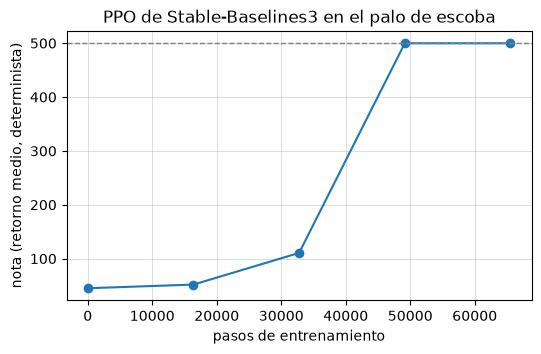

In [9]:
import time
import matplotlib.pyplot as plt

pasos, notas = [0], [media]
inicio = time.time()
for tramo in range(4):
    modelo.learn(total_timesteps=16_384, reset_num_timesteps=False)
    media, desviacion = evaluate_policy(modelo, entorno_examen, n_eval_episodes=10, deterministic=True)
    pasos.append(modelo.num_timesteps)
    notas.append(media)
    print(f"{modelo.num_timesteps:6d} pasos | nota {media:6.1f} ± {desviacion:5.1f} | σ {modelo.policy.log_std.exp().item():.3f} | {time.time() - inicio:4.0f} s")

plt.figure(figsize=(6, 3.5))
plt.plot(pasos, notas, "o-")
plt.axhline(500, color="gray", linestyle="--", linewidth=1)
plt.xlabel("pasos de entrenamiento")
plt.ylabel("nota (retorno medio, determinista)")
plt.title("PPO de Stable-Baselines3 en el palo de escoba")
plt.grid(True, alpha=0.4)
plt.show()


**Aprendido**: tras 49.152 pasos (6 lotes) ya saca la nota máxima, con los ajustes por defecto y **sin tocar nada**. (¿Por qué pedimos 16.384 y no 10.000 redondos? Porque SB3 juega siempre
lotes **completos** de 2048 × 4 = 8.192 pasos: si le pides 10.000, juega dos lotes enteros, 16.384, hasta pasarse de lo pedido. Mejor pedir múltiplos exactos del lote.)

Mira también la **σ**: empezó en 1 y ha ido bajando (a ~0,7). Como en el NB32-33, al aprender, el robot explora menos.

Para ponerlo en perspectiva: lo he contado, y nuestro PPO del NB33 necesitó unos **240.000 pasos** hasta superar los 490 (54 iteraciones de 32 episodios, que al principio eran cortos). SB3 lo ha
hecho con unas **cinco veces menos**. ¿Por qué? Hay varias diferencias: minilotes pequeños de 64 (muchísimos más pasos de Adam por lote, ejercicio E1), redes algo mayores... y la σ inicial
grande. En el ejercicio E3 comprobarás que esta última, sola, cambia muchísimo el resultado.


## 9 · Leer el informe de entrenamiento

Si creas el agente con **`verbose=1`**, SB3 imprime una tabla tras cada lote. Saber leerla es **imprescindible**: es el panel de instrumentos del entrenamiento, y de ahí sale casi todo el
diagnóstico de un problema. Hagamos un entrenamiento muy corto (dos lotes) con un agente nuevo, para ver la tabla:


In [10]:
modelo_charlatan = PPO("MlpPolicy", make_vec_env("PaloDeEscoba-v0", n_envs=4, seed=1), seed=1, verbose=1)
modelo_charlatan.learn(total_timesteps=2 * 8192)


/home/gregori/dev/robotica/venv/lib/python3.13/site-packages/gymnasium/envs/registration.py:729: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


Using cpu device


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 54.3     |
|    ep_rew_mean     | 45.4     |
| time/              |          |
|    fps             | 1504     |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 8192     |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 56.3        |
|    ep_rew_mean          | 47.2        |
| time/                   |             |
|    fps                  | 513         |
|    iterations           | 2           |
|    time_elapsed         | 31          |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.002032334 |
|    clip_fraction        | 0.00936     |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | 0.0481      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0187      |
|    n_updates            | 10          |
|    policy_gradient_loss | 5.74e-05    |
|    std                  | 1           |
|    value_loss           | 9.95        |
-----------------------------------------


(El aviso sobre `render_mode='rgb_array'` sale porque `make_vec_env` prepara las copias para poder **dibujarse**, y nuestro palo no sabe dibujarse, NB25. Para entrenar no importa nada.)

La primera tabla, tras el primer lote, aún no tiene la parte `train/`: todavía no ha entrenado. Ya sabes qué significa casi cada línea de la segunda. Las más importantes:

| Línea | Qué significa (con lo que ya sabes) | Qué vigilar |
|---|---|---|
| `rollout/ep_rew_mean` | El retorno medio de los últimos episodios terminados (lo apunta el `Monitor`). | Que **suba**. Es la curva del NB32-33. |
| `rollout/ep_len_mean` | La duración media de los episodios. | En el palo, que tienda a 500. |
| `time/fps` | Pasos por segundo (*frames per second*). | La velocidad: para calcular cuánto tardarás. |
| `train/approx_kl` | Cuánto ha cambiado la política en este lote (la **KL** del NB33, parecida a nuestro "cambio medio |r − 1|"). | Si se dispara (más de ~0,05), los pasos son demasiado grandes. |
| `train/clip_fraction` | La **fracción de datos recortados**: cuántos han llegado al freno. | Si es muy alta (más de ~0,3), la política "quiere" cambiar más de lo que se le deja: baja la tasa. |
| `train/entropy_loss` | Menos la entropía de la campana (NB33, E7): cuanto más negativa, más ancha. | Que no suba a toda prisa hacia 0 o más: la exploración se estaría hundiendo. |
| `train/explained_variance` | Qué parte de las variaciones de los retornos **explica el crítico** (1 = perfecto, 0 = nada, negativo = peor que predecir la media). | Que suba hacia 1: el crítico aprende. |
| `train/value_loss` | El error cuadrático del crítico. | Que no se dispare. |
| `train/std` | La σ actual de la campana. | Cómo evoluciona la exploración. |
| `train/policy_gradient_loss` | La pérdida truco del actor. | Nada: su valor no significa gran cosa (NB32). |

Fíjate en que **todos** estos instrumentos los has construido tú alguna vez en los notebooks anteriores (salvo `explained_variance`, que es una forma de medir lo bueno que es el crítico). Para
entrenamientos largos, SB3 puede mandar esta información a **TensorBoard**, un panel con gráficas en el navegador (`tensorboard_log="carpeta"` al crear el agente); lo usaremos en Colab.


## 10 · El examen, el uso y el guardado

El examen en el entorno oficial, con viento normal y con más viento, como en el NB32-33, usando `predict` con `deterministic=True`:


In [11]:
def examen(modelo, viento_maximo=30.0, n_episodios=20):
    entorno = gym.make("PaloDeEscoba-v0", viento_maximo=viento_maximo)
    retornos = []
    for episodio in range(n_episodios):
        observacion, info = entorno.reset(seed=1000 + episodio)
        retorno, terminado, truncado = 0.0, False, False
        while not (terminado or truncado):
            accion, _ = modelo.predict(observacion, deterministic=True)
            observacion, recompensa, terminado, truncado, info = entorno.step(accion)
            retorno += recompensa
        retornos.append(retorno)
    return np.array(retornos)

for viento in [30, 60, 80, 100]:
    r = examen(modelo, viento_maximo=viento)
    print(f"viento ±{viento:3d}: retorno medio {r.mean():6.1f} | caídas {(r < 400).sum():2d} de 20")


viento ± 30: retorno medio  499.8 | caídas  0 de 20


viento ± 60: retorno medio  499.7 | caídas  0 de 20


viento ± 80: retorno medio  425.2 | caídas  5 de 20


viento ±100: retorno medio  276.0 | caídas 12 de 20


Con el viento que conoce y con el doble, perfecto. Pero con ±80 y ±100 se cae bastantes veces más que nuestro PPO del NB33 (que con ±80 no se caía nunca). Aprendió **más rápido**, pero no
**más robusto**. Son dos cosas distintas, y en robótica real la segunda importa muchísimo (y, ojo, con una sola semilla de cada uno: es una pista, no una ley).

Y para guardarlo: **`modelo.save(ruta)`** crea un fichero **`.zip`** con todo dentro (las ruedecillas de las redes, los ajustes, el estado del optimizador). Y **`PPO.load(ruta)`** lo recupera:

In [12]:
from pathlib import Path

carpeta = Path("practica_nb34")
carpeta.mkdir(exist_ok=True)
modelo.save(carpeta / "ppo_palo")
print("Guardado:", sorted(p.name for p in carpeta.iterdir()))

modelo_cargado = PPO.load(carpeta / "ppo_palo")
observacion = np.array([5.0, -2.0], dtype=np.float32)
print("Original:", modelo.predict(observacion, deterministic=True)[0])
print("Cargado: ", modelo_cargado.predict(observacion, deterministic=True)[0])


Guardado: ['ppo_palo.zip']
Original: [-1.]
Cargado:  [-1.]


Las dos dan la misma acción. Una advertencia de **seguridad**, como en el NB26 y el NB31: el `.zip` de SB3 guarda parte de su contenido con **pickle** (los ajustes y algunos objetos), así que
cargar un modelo es, en parte, ejecutar lo que lleve dentro. **Carga solo modelos de fuentes de confianza.** Si necesitas compartir solo las redes, usa el `state_dict` de `modelo.policy` con
`torch.save` y `weights_only=True` al cargarlo (NB31).


## 11 · Tu primer robot de física real: el péndulo invertido de MuJoCo

Hasta ahora, el palo de escoba era **nuestro**: física de juguete, inventada en el NB11. Ha llegado el momento de pasar al simulador de verdad, **MuJoCo** (NB02), el mismo de los humanoides.
Gymnasium trae un entorno que es el primo profesional de nuestro palo: **`InvertedPendulum-v5`**, el **péndulo invertido**:

- Un **carrito** que se desliza sobre un raíl, con un **palo** unido por una bisagra (NB01). El robot no empuja el palo: empuja **el carrito**, y tiene que moverlo por debajo del palo para que no
  caiga, como cuando sostienes una escoba en la palma de la mano.
- **Observación**: 4 números (posición del carrito, ángulo del palo, y las velocidades de los dos).
- **Acción**: 1 número, la fuerza sobre el carrito, entre −3 y 3.
- **Recompensa**: +1 por cada paso con el palo de pie. El episodio termina si el palo se inclina más de 0,2 radianes (unos 11°; el **radián** es otra forma de medir ángulos, la que usan los simuladores: una vuelta entera son unos 6,28 radianes. Lo verás a fondo en el NB36), y se trunca a los 1.000 pasos: la nota máxima es **1.000**.

Todo con física real: masas, inercias, rozamientos, calculados por MuJoCo. Comprobémoslo (fíjate en el `float64` de la observación: MuJoCo calcula con decimales dobles, NB27):


In [13]:
import os
os.environ["MUJOCO_GL"] = "egl"          # dibujar sin pantalla (NB15)

pendulo = gym.make("InvertedPendulum-v5")
print("Observación:", pendulo.observation_space)
print("Acción:     ", pendulo.action_space)


Observación: Box(-inf, inf, (4,), float64)
Acción:      Box(-3.0, 3.0, (1,), float32)


Y ahora, lo bonito: **el mismo código** de SB3 que para el palo, cambiando **solo el nombre del entorno**. Esa es la gran ventaja del contrato de Gymnasium (NB25): cualquier algoritmo funciona con
cualquier entorno. Entrenamos 4 tramos de 16.384 pasos (alrededor de un minuto y medio en la Pi):


In [14]:
entornos_pendulo = make_vec_env("InvertedPendulum-v5", n_envs=4, seed=0)
agente_pendulo = PPO("MlpPolicy", entornos_pendulo, seed=0)
examen_pendulo = Monitor(gym.make("InvertedPendulum-v5"))

media, _ = evaluate_policy(agente_pendulo, examen_pendulo, n_eval_episodes=10, deterministic=True)
print(f"Sin entrenar: {media:.1f}")
inicio = time.time()
for tramo in range(4):
    agente_pendulo.learn(total_timesteps=16_384, reset_num_timesteps=False)
    media, desviacion = evaluate_policy(agente_pendulo, examen_pendulo, n_eval_episodes=10, deterministic=True)
    print(f"{agente_pendulo.num_timesteps:6d} pasos | nota {media:7.1f} ± {desviacion:5.1f} | {time.time() - inicio:4.0f} s")


Sin entrenar: 22.8


 16384 pasos | nota    98.3 ±  14.2 |   58 s


 32768 pasos | nota   145.3 ±  25.2 |  115 s


 49152 pasos | nota   175.7 ±  12.6 |  164 s


 65536 pasos | nota  1000.0 ±   0.0 |  219 s


Mira cómo es el aprendizaje: unos 85, luego ~150, ~175... y de golpe, **mil sobre mil**. Típico del RL: en cuanto el agente descubre cómo no caerse **nunca**, la nota salta del todo al máximo. Un robot simulado con física de verdad, que empezó sin saber nada, sostiene el péndulo durante todo el episodio. Y no hemos escrito ni una línea nueva de algoritmo.

Ahora, a **verlo**. Como en el NB15, creamos el entorno con `render_mode="rgb_array"` (cada `render()` devuelve una **foto**, una tabla de píxeles, NB14), jugamos un episodio con el agente,
guardamos una foto de cada dos pasos y las juntamos en un **GIF** animado con la biblioteca `imageio`:


100 fotos de (240, 320, 3)


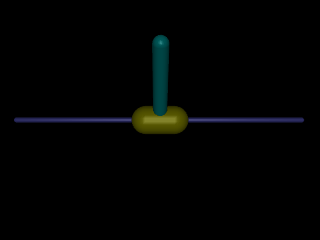

In [15]:
import imageio
from IPython.display import Image

camara = gym.make("InvertedPendulum-v5", render_mode="rgb_array", width=320, height=240)
observacion, info = camara.reset(seed=5)
fotos = []
for paso in range(200):
    accion, _ = agente_pendulo.predict(observacion, deterministic=True)
    observacion, recompensa, terminado, truncado, info = camara.step(accion)
    if paso % 2 == 0:
        fotos.append(camara.render())
    if terminado or truncado:
        break
camara.close()

os.makedirs("assets", exist_ok=True)
imageio.mimsave("assets/nb34_pendulo_ppo.gif", fotos, fps=25, loop=0)
print(f"{len(fotos)} fotos de {fotos[0].shape}")
Image(filename="assets/nb34_pendulo_ppo.gif")


Ahí lo tienes: el carrito (amarillo) hace pequeñas correcciones a izquierda y derecha, y el palo no se cae. Son 4 segundos de un episodio que dura 1.000 pasos; el agente lo sostiene
durante todos.

(`Image(filename=...)` muestra una imagen o un GIF en el cuaderno: tiene que ser la **última** línea de la celda, como cuando escribes una variable sola para ver su valor, NB05.)

Es un momento importante del curso: **la misma herramienta** (PPO de SB3), con el mismo código, sirve para el péndulo, para Hopper, para Walker2d y, con más cálculo, para el humanoide. A partir de ahora,
el reto ya no es el algoritmo: son los **cuerpos**, las **recompensas** y el **tiempo de cálculo**.


## 12 · Resumen de la lección

1. En el trabajo se usan **bibliotecas probadas**: menos fallos sutiles, trucos ya incluidos, idioma común. **Stable-Baselines3** (CPU, aprender), CleanRL (un fichero), RSL-RL e Isaac Lab
   (patas, GPU), Brax/MJX (JAX, miles de robots en GPU).
2. Entrenar: `PPO("MlpPolicy", entornos)`, `learn(total_timesteps=...)`, `predict(obs, deterministic=True)`, `evaluate_policy`, `save`/`load`.
3. El **diccionario** NB33 → SB3: `n_steps`×`n_envs` (lote en pasos), `batch_size`, `n_epochs`, `learning_rate`, `gamma`, `gae_lambda`, `clip_range`, `ent_coef`, `vf_coef`, `max_grad_norm`,
   `log_std_init` (σ = 1 por defecto).
4. **Entornos vectorizados** (`make_vec_env`): varias copias a la vez, con reinicio automático y `Monitor`.
5. Por dentro, la política es un actor-crítico (64-64, Tanh, `log_std`) y `PPO.train` contiene **tu** razón, tu normalización y tu recorte (lo leímos con `inspect`).
6. El **informe** de `verbose=1`: `ep_rew_mean`, `approx_kl`, `clip_fraction`, `entropy_loss`, `explained_variance`, `std`... el panel de instrumentos.
7. Primer robot MuJoCo: **`InvertedPendulum-v5`**, 1.000 sobre 1.000 en unos 65.000 pasos, **sin cambiar el código**, y filmado en GIF.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Stable-Baselines3 (SB3)** | Biblioteca de algoritmos de RL en PyTorch. |
| **`MlpPolicy`** | Política con redes de capas lineales (perceptrón multicapa). |
| **`total_timesteps`** | Pasos de entorno totales de un entrenamiento. |
| **`n_steps` / `batch_size` / `n_epochs`** | Pasos por copia y lote / tamaño del minilote / épocas. |
| **`clip_range` / `gae_lambda` / `ent_coef`** | El ε del recorte / el λ de GAE / el peso de la entropía. |
| **Entorno vectorizado** | Varias copias de un entorno que avanzan a la vez. |
| **`Monitor`** | Envoltorio que apunta retorno y duración de cada episodio. |
| **`evaluate_policy`** | Jugar episodios y devolver media y desviación del retorno. |
| **`approx_kl` / `clip_fraction`** | Cuánto cambió la política / qué fracción de datos llegó al freno. |
| **`explained_variance`** | Qué parte de los retornos explica el crítico (1 = perfecto). |
| **TensorBoard** | Panel de gráficas del entrenamiento, en el navegador. |
| **`InvertedPendulum-v5`** | El péndulo invertido de MuJoCo: carrito + palo, nota máxima 1.000. |


## 13 · Ejercicios

**E1.** Con `n_envs=8` y `n_steps=1024`, ¿cuántos pasos tiene cada lote? Con `batch_size=256`, ¿cuántos minilotes salen por época, y cuántos pasos de Adam por lote con 10 épocas?

**E2.** Mirando el informe de `verbose=1`, un compañero te dice: "`clip_fraction` está en 0,45 y `approx_kl` en 0,12". ¿Qué le dirías que pruebe?

**E3.** Entrena en el palo de escoba un agente con **nuestra** σ inicial: `PPO("MlpPolicy", entornos, seed=0, policy_kwargs=dict(log_std_init=np.log(0.25)))`, 50.000 pasos, y compara su nota con la del
apartado 8. ¿Qué crees que pasa y por qué?

**E4.** Crea un agente con `policy_kwargs=dict(net_arch=dict(pi=[32], vf=[64]))` e imprime su `policy`. ¿A qué notebook se parece esa arquitectura?

**E5.** Con el agente del péndulo, examina 20 episodios con `deterministic=False` (sorteando de la campana). ¿Baja la nota?

**E6.** **Reto.** Entrena PPO en **`Pendulum-v1`** (el péndulo que hay que **levantar** desde abajo, sin MuJoCo) durante 100.000 pasos con los ajustes por defecto. Su recompensa es siempre negativa (un
castigo por estar lejos de arriba y por gastar fuerza): una nota cercana a −200 es buena, y alrededor de −1.200 es no saber nada. ¿Lo consigue? (Pista: probablemente no del todo; busca en la
documentación de SB3 o en el "RL Zoo" los ajustes que se usan para él.)


<details>
<summary>▶ Solución E1</summary>

Lote: 8 × 1024 = **8.192 pasos**. Minilotes por época: 8.192 / 256 = **32**. Pasos de Adam por lote: 32 × 10 épocas = **320**. (Con los ajustes por defecto, 8.192 / 64 × 10 = 1.280: SB3 da
muchísimos pasos pequeños.)
</details>

<details>
<summary>▶ Solución E2</summary>

Las dos señales dicen lo mismo: la política **cambia demasiado** en cada lote. Casi la mitad de los datos llegan al freno (el recorte trabaja a destajo) y la KL es alta. Lo primero que se prueba es
**bajar la tasa** (`learning_rate`), y si no basta, **menos épocas** (`n_epochs`) o minilotes más grandes (`batch_size`): menos pasos por lote. Es la fragilidad del NB32-33, vista desde el panel
de instrumentos.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
agente_estrecho = PPO("MlpPolicy", make_vec_env("PaloDeEscoba-v0", n_envs=4, seed=0), seed=0,
                      policy_kwargs=dict(log_std_init=np.log(0.25)))
agente_estrecho.learn(total_timesteps=50_000)
print(evaluate_policy(agente_estrecho, gym.make("PaloDeEscoba-v0"), n_eval_episodes=10, deterministic=True))
```

Medido: con σ inicial 0,25, tras 50.000 pasos el agente **aún no ha aprendido nada** (nota ~51, la del azar), cuando el agente por defecto ya sacaba 500. Probándolo más largo, necesitó
unos **250.000 pasos**: cinco veces más.

¿Por qué, si en nuestro NB33 σ = 0,25 funcionaba? Porque el palo se cae en unas decenas de pasos al principio, y con una campana estrecha el agente prueba empujes muy parecidos entre sí: le cuesta
**descubrir** que empujar fuerte hacia el lado correcto salva el palo. Con σ = 1 prueba de todo desde el principio y encuentra antes la pista. Moraleja: **la exploración inicial es un
hiperparámetro de primera**, y lo que funciona con un algoritmo y unos ajustes no tiene por qué funcionar con otros.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
print(PPO("MlpPolicy", entornos, policy_kwargs=dict(net_arch=dict(pi=[32], vf=[64]))).policy)
```

El actor queda 2 → 32 → 1 y el crítico 2 → 64 → 1: **nuestras redes del NB32-33** (salvo que el crítico de SB3 no ve el reloj). `net_arch` es el ajuste para cambiar el tamaño de las redes, y es de los
que más se tocan: para el humanoide se suelen usar redes de 256 o 512 neuronas por capa.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
media, desv = evaluate_policy(agente_pendulo, examen_pendulo, n_eval_episodes=20, deterministic=False)
print(media, desv)
```

Medido: con la acción media saca **1.000 ± 0**; sorteando de la campana, **929 ± 164** (algunos episodios se caen). La σ del agente sigue siendo bastante grande al final (~0,66, con acciones
entre −3 y 3), y el ruido a veces lo desestabiliza. Por eso, para **trabajar**, se usa la acción media (determinista).
</details>

<details>
<summary>▶ Solución E6</summary>

```python
agente = PPO("MlpPolicy", make_vec_env("Pendulum-v1", n_envs=4, seed=0), seed=0)
agente.learn(total_timesteps=100_000)
print(evaluate_policy(agente, gym.make("Pendulum-v1"), n_eval_episodes=10, deterministic=True))
```

Medido: **−1.031 ± 221**: **no** lo consigue, sigue casi como al principio. `Pendulum-v1` es famoso por eso: con los ajustes por defecto, PPO no lo aprende en 100.000 pasos. En el **RL Zoo** de SB3 (la
colección oficial de ajustes probados, en GitHub) verás que para Pendulum usan, entre otras cosas, `n_steps=1024`, `gae_lambda=0.95`, `gamma=0.9`, `use_sde=True` y una tasa más alta. Buscar y
probar ajustes que ya funcionaron a otros es parte del oficio: **nunca empieces de cero si alguien ya publicó los ajustes**.
</details>


## 14 · 🛠 Práctica en MuJoCo: SB3 en tu propio palo de escoba

En la sección 11 entrenaste SB3 en el péndulo de MuJoCo **de Gymnasium**, que escribió otra persona. Pero tú tienes **tu propio** palo de
escoba de MuJoCo: el de `robots/palo_escoba.xml`, que convertiste en entorno de Gymnasium en la práctica del NB25 y con el que entrenaste
REINFORCE en la del NB29. Hoy le toca a la herramienta profesional:

1. traerás tu entorno y lo pasarás por el verificador de SB3;
2. lo entrenarás con PPO de SB3, con los ajustes por defecto (algo más de un minuto);
3. y lo **compararás** en el mismo examen con dos controladores que ya conoces: el **PD a mano** (NB23-NB24) y la neurona de
   **REINFORCE** (práctica del NB29).

Spoiler: la comparación tiene sorpresa, y enseña algo importante sobre las recompensas.


### Paso 1 · Tu entorno, otra vez

Es la clase de la práctica del NB25, sin el dibujo (para el vídeo usaremos el `taller`). Recuerda sus reglas: observa 4 números (posición
del carro, ángulo del palo y sus dos velocidades), actúa con 1 (la orden del motor, de −1 a 1), gana +1 por paso y pierde si el palo pasa de
45° **o** si el carro llega al final del raíl (1,7 m). Dura 500 pasos de 0,01 s: 5 segundos.


In [16]:
import mujoco
import taller

RUTA_PALO = os.path.join(os.path.dirname(taller.__file__), "robots", "palo_escoba.xml")

class PaloEscobaMuJoCoEnv(gym.Env):
    def __init__(self, viento_maximo=0.0):
        super().__init__()
        self.modelo = mujoco.MjModel.from_xml_path(RUTA_PALO)
        self.datos = mujoco.MjData(self.modelo)
        self.viento_maximo = viento_maximo
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(4,), dtype=np.float64)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        mujoco.mj_resetData(self.modelo, self.datos)
        self.datos.qpos[1] = self.np_random.uniform(-0.1, 0.1)      # palo algo inclinado
        mujoco.mj_forward(self.modelo, self.datos)
        return self._observacion(), {}

    def step(self, action):
        self.datos.ctrl[0] = np.clip(action[0], -1.0, 1.0)
        self.datos.qfrc_applied[1] = self.np_random.uniform(-self.viento_maximo, self.viento_maximo)   # viento
        mujoco.mj_step(self.modelo, self.datos)
        x, angulo = self.datos.qpos
        terminado = bool(abs(angulo) > 0.785 or abs(x) > 1.7)
        return self._observacion(), 0.0 if terminado else 1.0, terminado, False, {}

    def _observacion(self):
        return np.concatenate([self.datos.qpos, self.datos.qvel])

gym.register(id="PaloEscobaMuJoCo-v0", entry_point=PaloEscobaMuJoCoEnv, max_episode_steps=500)
check_env(PaloEscobaMuJoCoEnv())
print("Tu palo de MuJoCo, registrado y verificado por SB3")

Tu palo de MuJoCo, registrado y verificado por SB3


(`os`, `gym`, `spaces`, `np` y `check_env` ya están importados de las secciones anteriores.)

### Paso 2 · Entrenar con SB3

Exactamente el código de la sección 8, cambiando el nombre del entorno: 4 copias, PPO por defecto, semilla 0. Le damos **4 lotes**
(4 × 8.192 = 32.768 pasos de física):


In [17]:
inicio = time.time()
agente_mj = PPO("MlpPolicy", make_vec_env("PaloEscobaMuJoCo-v0", n_envs=4, seed=0), seed=0)
agente_mj.learn(total_timesteps=32_768)
print(f"Entrenado en {time.time() - inicio:.0f} s")

Entrenado en 71 s


### Paso 3 · El examen: tres controladores, los mismos 20 palos

Para comparar de forma justa, los tres controladores juegan **los mismos** 20 episodios (las semillas 100 a 119 deciden la inclinación
inicial de cada palo). Además de la nota, apuntamos **cómo termina** cada episodio: aguanta los 5 s, se le cae el palo, o el carro se
sale del raíl.

Cada controlador es una función que recibe la observación y devuelve la acción (como las políticas del NB35, con `lambda`, NB23):


In [18]:
politica_sb3 = lambda obs: agente_mj.predict(obs, deterministic=True)[0]
politica_pd = lambda obs: np.clip([3 * obs[1] + 0.8 * obs[3] + 0.1 * obs[0] + 0.2 * obs[2]], -1, 1)    # NB23-NB24
politica_reinforce = lambda obs: np.clip([2.2 * obs[1] + 0.35 * obs[3]], -1, 1)                          # práctica del NB29

def examen_mujoco(politica, viento=0.0, n=20):
    entorno = gym.make("PaloEscobaMuJoCo-v0", viento_maximo=viento)
    retornos, finales = [], []
    for episodio in range(n):
        observacion, info = entorno.reset(seed=100 + episodio)
        retorno, terminado, truncado = 0.0, False, False
        while not (terminado or truncado):
            observacion, recompensa, terminado, truncado, info = entorno.step(politica(observacion))
            retorno += recompensa
        retornos.append(retorno)
        if abs(observacion[1]) > 0.785:
            finales.append("palo")
        elif abs(observacion[0]) > 1.7:
            finales.append("raíl")
        else:
            finales.append("aguanta")
    return np.mean(retornos), finales

Y los tres, al examen:

In [19]:
for nombre, politica in [("SB3 (PPO)", politica_sb3), ("PD a mano", politica_pd), ("REINFORCE", politica_reinforce)]:
    nota, finales = examen_mujoco(politica)
    print(f"{nombre:>10}: nota {nota:5.1f} de 500 | aguanta {finales.count('aguanta'):2d} | "
          f"se sale del raíl {finales.count('raíl'):2d} | se cae el palo {finales.count('palo'):2d}")

 SB3 (PPO): nota 486.8 de 500 | aguanta 13 | se sale del raíl  7 | se cae el palo  0


 PD a mano: nota 500.0 de 500 | aguanta 20 | se sale del raíl  0 | se cae el palo  0


 REINFORCE: nota 422.4 de 500 | aguanta  6 | se sale del raíl 14 | se cae el palo  0


Fíjate bien en la columna de la derecha y en la del medio:

- **SB3** aprende en algo más de un minuto a **no dejar caer el palo nunca** (0 de 20), y saca casi 490 de 500. Pero en **7** de los 20
  episodios el carro acaba **saliéndose del raíl**.
- La neurona de **REINFORCE** del NB29 tampoco deja caer el palo, pero se sale del raíl en **14** de 20: ella ni siquiera **ve** el carro
  (solo miraba el ángulo y su velocidad), así que no tiene forma de saber que se acerca al final.
- El **PD a mano**, con sus cuatro números, saca un **500 perfecto**: nunca se cae y nunca se sale. Tiene dos términos para el carro
  (0,1 · x + 0,2 · velocidad del carro) que lo devuelven suavemente al centro.

¿Por qué SB3, que **sí** ve el carro, se sale? Mira la **recompensa**: +1 por paso **sin caerse**. No dice nada de "quédate en el centro".
Para el agente, un carro en el centro y uno a 1,6 m valen lo mismo... hasta que llega a 1,7 m y se acaba. En 5 segundos, ir a la deriva
casi nunca le cuesta nada, así que con 4 lotes de experiencia no ha aprendido a evitarlo. Es la lección del NB04 y del NB35 otra vez: **el
agente optimiza lo que pagas**, y una recompensa que solo castiga el desastre final enseña muy despacio a evitarlo.

Y otra lección, más incómoda: en un problema pequeño y bien entendido, un controlador **diseñado a mano** con cuatro números puede ganar a
dos redes con más de 9.000 ruedecillas. El RL brilla cuando el problema es demasiado complicado para diseñarlo a mano (un robot con patas, NB35),
no en todo.


### Paso 4 · Míralo

El agente de SB3 controlando el palo de MuJoCo con el `video` del taller, durante 5 segundos, empezando con el palo inclinado 0,08 rad. La
función de control lee `qpos` y `qvel`, se los pasa al agente y escribe su orden en `datos.ctrl`. De paso, apunta dónde está el carro en cada
pasito:


In [20]:
modelo_palo, datos_palo = taller.cargar("palo_escoba")
datos_palo.qpos[1] = 0.08
mujoco.mj_forward(modelo_palo, datos_palo)
posiciones_carro = []

def control_sb3(modelo, datos):
    observacion = np.concatenate([datos.qpos, datos.qvel])
    datos.ctrl[0] = agente_mj.predict(observacion, deterministic=True)[0][0]
    posiciones_carro.append(datos.qpos[0])

taller.video(modelo_palo, datos_palo, segundos=5, control=control_sb3, nombre="nb34_palo_sb3", distancia=4.5, seguir=False)
print(f"el carro llega a x = {max(posiciones_carro, key=abs):+.2f} m (el raíl acaba en ±1,8 m)")

el carro llega a x = +1.80 m (el raíl acaba en ±1,8 m)


El palo no se cae en ningún momento: el carro hace sus correcciones a izquierda y derecha, muy bien. Pero fíjate en **dónde** las hace:
el carro se va desplazando hacia la derecha a trompicones (a los 2 s ya está a unos 60 cm del centro) y, a los 5 s, llega al **tope** del
raíl, a 1,8 m. En el examen, ese episodio habría terminado al pasar de 1,7 m. Es el defecto del Paso 3, visto con tus propios ojos.

### Tus retos

**Reto 1.** Examina a SB3 y al PD con **viento** (el `viento_maximo` del entorno empuja la bisagra del palo al azar en cada paso, en N·m):
`examen_mujoco(politica, viento=v)` con v = 0,5, 1 y 2. ¿Cuál aguanta mejor?

**Reto 2.** Arregla la recompensa: crea una clase hija (NB25) de `PaloEscobaMuJoCoEnv` cuyo `step` reste a la recompensa una penalización
por estar lejos del centro, `1.0 * x²`, regístrala como `PaloCentrado-v0` y entrena otro agente igual que en el Paso 2, pero por tramos de
2 lotes hasta 98.304 pasos, examinándolo tras cada tramo con `examen_mujoco` (que usa el entorno **original**, así que la nota es
comparable). ¿Se sale menos del raíl? (Tarda varios minutos en la Pi: hazlo cuando tengas tiempo, o en Colab.)

<details>
<summary>▶ Solución Reto 1</summary>

```python
for viento in [0.5, 1.0, 2.0]:
    for nombre, politica in [("SB3", politica_sb3), ("PD", politica_pd)]:
        nota, finales = examen_mujoco(politica, viento=viento)
        print(f"viento {viento}: {nombre:>3} nota {nota:5.1f} | raíl {finales.count('raíl'):2d} | palo {finales.count('palo'):2d}")
```

Medido: el PD saca **500** con 0,5 y con 1, y 471 con 2 (se sale del raíl 4 veces). SB3 baja a 477 y 469 (se sale del raíl 8 y 10 veces) y,
con 2, a **406**: se sale 12 veces y **se le cae el palo** 3. El viento empuja el carro a la deriva más deprisa, y el agente que no aprendió a
volver al centro lo paga. Ojo, como siempre: una semilla de entrenamiento y 20 episodios; es una pista, no una ley (NB34, sección 10).
</details>

<details>
<summary>▶ Solución Reto 2</summary>

```python
class PaloCentrado(PaloEscobaMuJoCoEnv):
    def step(self, action):
        observacion, recompensa, terminado, truncado, info = super().step(action)
        if not terminado:
            recompensa = recompensa - 1.0 * observacion[0] ** 2     # castigo por alejarse del centro
        return observacion, recompensa, terminado, truncado, info

gym.register(id="PaloCentrado-v0", entry_point=PaloCentrado, max_episode_steps=500)
agente_centrado = PPO("MlpPolicy", make_vec_env("PaloCentrado-v0", n_envs=4, seed=0), seed=0)
for tramo in range(6):
    agente_centrado.learn(total_timesteps=16_384, reset_num_timesteps=False)
    nota, finales = examen_mujoco(lambda obs: agente_centrado.predict(obs, deterministic=True)[0])
    print(agente_centrado.num_timesteps, round(nota, 1), "raíl", finales.count("raíl"), "palo", finales.count("palo"))
```

Medido (y lo mismo con el entorno original, para comparar):

| pasos | con penalización: nota, raíl, palo | original: nota, raíl, palo |
|---|---|---|
| 32.768 | 269,7 · 0 · **20** | 486,8 · 7 · 0 |
| 49.152 | 355,5 · 0 · 19 | 448,8 · 14 · 0 |
| 65.536 | 495,5 · 0 · 5 | 448,8 · 7 · 0 |
| 81.920 | **500 · 0 · 0** | 480,2 · 6 · 0 |
| 98.304 | 500 · 0 · 0 | 500 · 0 · 0 |

Al principio, la penalización **estorba**: con 32.768 pasos el agente nuevo deja caer el palo en los 20 episodios (aprender a la vez
"no lo tires" y "no te alejes" es más difícil). Pero **desde el principio no se sale nunca del raíl**, y a los 81.920 pasos ya es
perfecto, mientras que el original todavía se sale 6 veces y necesita 98.304 para llegar al 500. Moldear la recompensa no es gratis ni
mágico: cambia **qué** aprende primero. (Y, como siempre, con una sola semilla.) Lo verás a fondo en el NB44.
</details>

### Qué has aprendido de MuJoCo hoy

- **Tu** entorno de MuJoCo (un `gym.Env` con `MjModel`/`MjData` dentro) funciona con SB3 **sin cambiar nada**: verificador, `make_vec_env`,
  `PPO`, `predict`.
- `datos.qfrc_applied` como **perturbación** (viento) para examinar la robustez.
- Usar un agente de SB3 como función de control de una simulación de MuJoCo (`taller.video` con `control=`).
- Comparar con un examen justo (mismas semillas) y mirar **cómo** falla cada controlador, no solo la nota.
- La recompensa manda: si no paga "quédate en el centro", el agente no lo aprende (o lo aprende muy despacio).

En la práctica del NB35 abrirás el **plano MJCF de Hopper** por dentro, le cambiarás el cuerpo y verás qué le pasa a un campeón entrenado.


## 15 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Con este notebook cierras el bloque de algoritmos: de REINFORCE (NB29) a PPO profesional (NB34), entendiendo cada pieza. A partir de ahora el protagonista cambia: ya no es el algoritmo, es el
**cuerpo**. En la próxima lección, los primeros robots **con patas** de MuJoCo: **Hopper** (una pata que salta) y **Walker2d** (dos piernas, en un plano). Ahí aparecerán problemas nuevos y muy
reales: recompensas que se pueden engañar (NB04), robots que aprenden a moverse de formas raras, y entrenamientos que ya no caben en un par de minutos.
